In [1]:
# 第一次实验

import matplotlib.pyplot as plt
import yfinance as yf

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

nvda = yf.download('NVDA', period='6mo', progress=False, multi_level_index=False)

print(f'all {len(nvda)} days')
print(f'收盘价 ${nvda["Close"].iloc[-1]:.2f} ')
display(nvda)

fig, axes = plt.subplots(2,1, figsize=(12,6), sharex=True, gridspec_kw={'height_ratios':[3,1]})

axes[0].plot(nvda.index, nvda['Close'], color='tab:blue', linewidth=1.5)
axes[0].set_title('真实数据 · nvidia 收盘价', fontsize=14)
axes[0].set_ylabel('美元')
axes[0].grid(True, alpha=0.3)

axes[1].bar(nvda.index, nvda['Volume'], width=0.8, color='gray',alpha=0.5)
axes[1].set_ylabel('成交量')
axes[1].set_xlabel('日期')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

YF.download() has changed argument auto_adjust default to True



1 Failed download:
['NVDA']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


all 0 days


IndexError: single positional indexer is out-of-bounds

In [2]:
# 2 量化实验
import warnings
warnings.filterwarnings('ignore')

import os
import sys
import numpy as np
import pandas as pd
import matplotlib
# 在命令行运行(非Jupyter)时自动切到非交互后端，避免 plt.show() 报错
if 'ipykernel' not in sys.modules and 'IPython' not in sys.modules:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import akshare as ak
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows 黑体；Mac 可改 PingFang SC
plt.rcParams['axes.unicode_minus'] = False     # 负号正常显示

# 图片输出目录
try:
    # 脚本环境
    base_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # Notebook 环境，回退到当前工作目录
    base_dir = os.getcwd()
IMG_DIR = os.path.join(os.path.dirname(base_dir), 'images')
os.makedirs(IMG_DIR, exist_ok=True)
img_counter = 0


def show_or_save(title="figure"):
    """根据运行环境自动选择显示或保存图片。
    在 Jupyter 中 → plt.show() 直接显示
    在命令行中 → 保存到 images/ 目录
    """
    global img_counter
    img_counter += 1
    in_interactive = ('ipykernel' in sys.modules) or ('IPython' in sys.modules)
    if in_interactive:
        plt.show()
    else:
        fname = f"{img_counter:02d}_{title}.png"
        fpath = os.path.join(IMG_DIR, fname)
        plt.savefig(fpath, dpi=150, bbox_inches='tight')
        print(f'  [图片已保存] {fpath}')
    plt.close()

print(f'akshare 版本: {ak.__version__}')
print('=' * 60)

# ============================================================
# 第0部分：多数据源适配 —— 自动选择可用的数据源
# ============================================================
print('0. 检测可用数据源...')
print('-' * 40)


def get_a_stock_daily(symbol, start_date, end_date, adjust="hfq"):
    """
    获取A股日线数据，自动选择可用数据源。

    参数:
        symbol:   股票代码，如 "600519"（不需要 sh/sz 前缀）
        start_date: 开始日期 "YYYYMMDD"
        end_date:   结束日期 "YYYYMMDD"
        adjust:     复权方式 "hfq"(后复权,推荐) / "qfq"(前复权) / ""(不复权)

    返回:
        DataFrame，列名统一为: date/open/high/low/close/volume
    """
    # 方案A：东方财富（推荐首选，数据质量高）
    try:
        df = ak.stock_zh_a_hist(
            symbol=symbol, period="daily",
            start_date=start_date, end_date=end_date, adjust=adjust
        )
        df = df.rename(columns={
            '日期': 'date', '开盘': 'open', '收盘': 'close',
            '最高': 'high', '最低': 'low', '成交量': 'volume'
        })
        print(f'  [东方财富] {symbol}: {len(df)} 天')
        return df
    except Exception:
        pass

    # 方案B：新浪（需要 sh/sz 前缀）
    try:
        prefix = 'sh' if symbol.startswith(('6', '9')) else 'sz'
        df = ak.stock_zh_a_daily(
            symbol=f'{prefix}{symbol}',
            start_date=start_date, end_date=end_date, adjust=adjust
        )
        df = df.rename(columns={
            'date': 'date', 'open': 'open', 'close': 'close',
            'high': 'high', 'low': 'low', 'volume': 'volume'
        })
        print(f'  [新浪] {prefix}{symbol}: {len(df)} 天')
        return df
    except Exception:
        pass

    # 方案C：腾讯（sz/sh 前缀格式，注意列名可能不同）
    try:
        prefix = 'sh' if symbol.startswith(('6', '9')) else 'sz'
        df = ak.stock_zh_a_hist_tx(
            symbol=f'{prefix}{symbol}',
            start_date=start_date, end_date=end_date, adjust=adjust
        )
        # 腾讯源可能返回不同的列名，统一映射
        col_map = {}
        for c in df.columns:
            if c in ('日期', 'date'): col_map[c] = 'date'
            elif c in ('开盘', 'open'): col_map[c] = 'open'
            elif c in ('收盘', 'close'): col_map[c] = 'close'
            elif c in ('最高', 'high'): col_map[c] = 'high'
            elif c in ('最低', 'low'): col_map[c] = 'low'
            elif c in ('成交量', 'volume'): col_map[c] = 'volume'
            elif c in ('成交额', 'amount'): col_map[c] = 'amount'
        df = df.rename(columns=col_map)
        if 'volume' not in df.columns and 'amount' in df.columns:
            df['volume'] = 0
        print(f'  [腾讯] {prefix}{symbol}: {len(df)} 天')
        return df
    except Exception as e:
        raise RuntimeError(f'所有数据源均不可用！最后错误: {e}')


def get_index_daily(symbol):
    """
    获取指数日线，自动选择可用数据源。

    参数:
        symbol: 指数代码，如 "sh000001"(上证) / "sz399001"(深证) / "sh000300"(沪深300)
    """
    # 方案A：新浪（老牌，稳定）
    try:
        df = ak.stock_zh_index_daily(symbol=symbol)
        print(f'  [新浪] {symbol}: {len(df)} 天')
        return df
    except Exception:
        pass

    # 方案B：腾讯
    try:
        df = ak.stock_zh_index_daily_tx(symbol=symbol)
        print(f'  [腾讯] {symbol}: {len(df)} 天')
        return df
    except Exception:
        pass

    # 方案C：东方财富
    try:
        df = ak.stock_zh_index_daily_em(symbol=symbol)
        print(f'  [东方财富] {symbol}: {len(df)} 天')
        return df
    except Exception as e:
        raise RuntimeError(f'所有数据源均不可用！最后错误: {e}')

df_test = get_a_stock_daily("600522","20240101","20260615", adjust="hfq")
print(f'列名{df_test.columns.tolist()}')
display(df_test.head())
display(df_test.tail(10))

print('环境就绪 ✓')



akshare 版本: 1.18.64
0. 检测可用数据源...
----------------------------------------
  [东方财富] 600522: 591 天
列名['date', '股票代码', 'open', 'close', 'high', 'low', 'volume', '成交额', '振幅', '涨跌幅', '涨跌额', '换手率']


,date,股票代码,open,close,high,low,volume,成交额,振幅,涨跌幅,涨跌额,换手率
0,2024-01-02,600522,78.78,78.14,79.37,78.08,322385,401725385.0,1.64,-0.67,-0.53,0.94
1,2024-01-03,600522,77.96,77.56,78.78,76.68,333977,411139419.0,2.69,-0.74,-0.58,0.98
2,2024-01-04,600522,77.50,76.44,77.50,75.98,247761,300169387.0,1.96,-1.44,-1.12,0.73
3,2024-01-05,600522,76.44,74.22,76.74,73.99,424510,503787154.0,3.60,-2.90,-2.22,1.24
4,2024-01-08,600522,74.16,73.05,75.04,72.99,301890,352702491.0,2.76,-1.58,-1.17,0.88


,date,股票代码,open,close,high,low,volume,成交额,振幅,涨跌幅,涨跌额,换手率
581,2026-06-02,600522,236.96,259.54,262.11,236.96,4059782,1.706939e+10,10.52,8.57,20.48,11.90
582,2026-06-03,600522,265.39,271.77,283.47,262.52,4191823,1.896276e+10,8.07,4.71,12.23,12.28
583,2026-06-04,600522,264.92,278.08,284.64,264.92,3543682,1.627420e+10,7.26,2.32,6.31,10.38
584,2026-06-05,600522,272.35,278.14,297.45,271.59,4065648,1.920093e+10,9.30,0.02,0.06,11.91
585,2026-06-08,600522,266.03,298.38,305.11,266.03,5131565,2.520513e+10,14.05,7.28,20.24,15.04
586,2026-06-09,600522,304.23,327.34,327.34,292.71,4848082,2.497789e+10,11.61,9.71,28.96,14.20
587,2026-06-10,600522,315.76,302.30,323.30,296.34,3836724,1.956162e+10,8.24,-7.65,-25.04,11.24
588,2026-06-11,600522,299.32,296.86,306.98,289.73,2899092,1.436316e+10,5.71,-1.80,-5.44,8.49
589,2026-06-12,600522,305.34,292.94,314.00,292.88,3301235,1.653254e+10,7.11,-1.32,-3.92,9.67
590,2026-06-15,600522,300.96,309.03,309.73,282.88,3099242,1.542331e+10,9.17,5.49,16.09,9.08


环境就绪 ✓


  [东方财富] 600522: 591 天


1     -0.007423
2     -0.014440
3     -0.029042
4     -0.015764
5     -0.006434
         ...   
586    0.097057
587   -0.076495
588   -0.017995
589   -0.013205
590    0.054926
Name: close, Length: 590, dtype: float64

(array([ 1.,  0.,  1.,  3.,  3.,  1.,  1.,  2.,  8.,  8., 14., 15., 22.,
        28., 52., 68., 58., 81., 51., 28., 34., 24., 13., 13., 12., 11.,
        10.,  7.,  4.,  6.,  5.,  1.,  1.,  0.,  4.]),
 array([-0.09190274, -0.08650388, -0.08110502, -0.07570616, -0.07030729,
        -0.06490843, -0.05950957, -0.05411071, -0.04871184, -0.04331298,
        -0.03791412, -0.03251526, -0.02711639, -0.02171753, -0.01631867,
        -0.01091981, -0.00552094, -0.00012208,  0.00527678,  0.01067564,
         0.01607451,  0.02147337,  0.02687223,  0.03227109,  0.03766996,
         0.04306882,  0.04846768,  0.05386654,  0.05926541,  0.06466427,
         0.07006313,  0.07546199,  0.08086086,  0.08625972,  0.09165858,
         0.09705744]),
 <BarContainer object of 35 artists>)

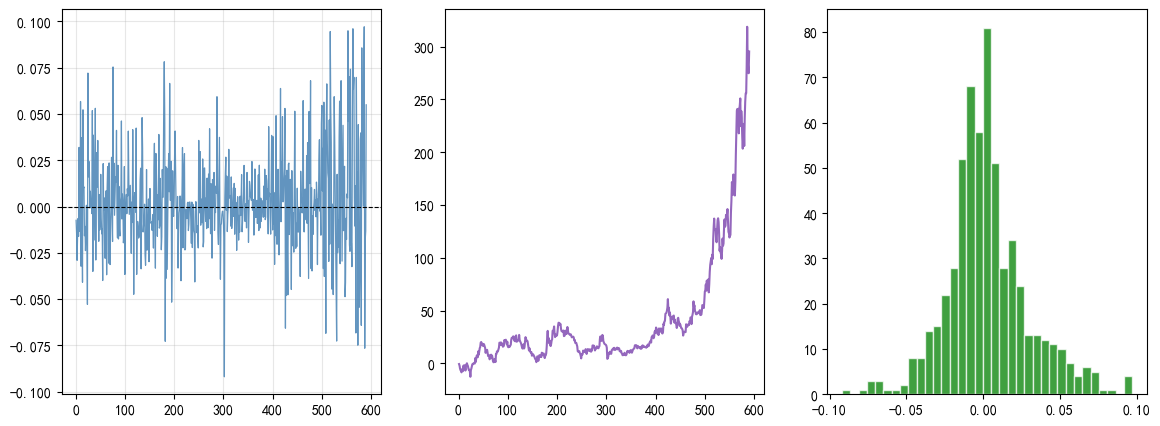

In [3]:
data  = get_a_stock_daily("600522","20240101","20260615", adjust="hfq")

df = data['close'].pct_change().dropna()
display(df)

rets = df
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].plot(rets.index, rets.values, color='steelblue',linewidth=0.9, alpha=0.85)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].grid(True, alpha=0.3)

cum_return = (1 + rets).cumprod()-1
axes[1].plot(cum_return.index, cum_return.values*100, color='tab:purple', linewidth=1.5)

axes[2].hist(rets.values, bins=35, color='green', alpha=0.75, edgecolor='white')


In [4]:
# 3 移动平均线策略 
data  = get_a_stock_daily("600522","20240101","20260616", adjust="hfq")

df = data['close'].dropna().copy()
display(df)
df = data[['close']].dropna().copy()
df.columns=['close']
df['MA5'] = df['close'].rolling(5).mean()
df['MA20'] = df['close'].rolling(20).mean()
print('---------------------')
display(df)

  [新浪] sh600522: 592 天


0      107.50
1      106.63
2      104.98
3      101.69
4       99.96
        ...  
587    451.03
588    442.68
589    436.66
590    461.36
591    486.52
Name: close, Length: 592, dtype: float64

---------------------


,close,MA5,MA20
0,107.50,NaN,NaN
1,106.63,NaN,NaN
2,104.98,NaN,NaN
3,101.69,NaN,NaN
4,99.96,104.152,NaN
...,...,...,...
587,451.03,442.656,396.8750
588,442.68,448.426,399.1980
589,436.66,452.974,402.6170
590,461.36,456.244,405.9410


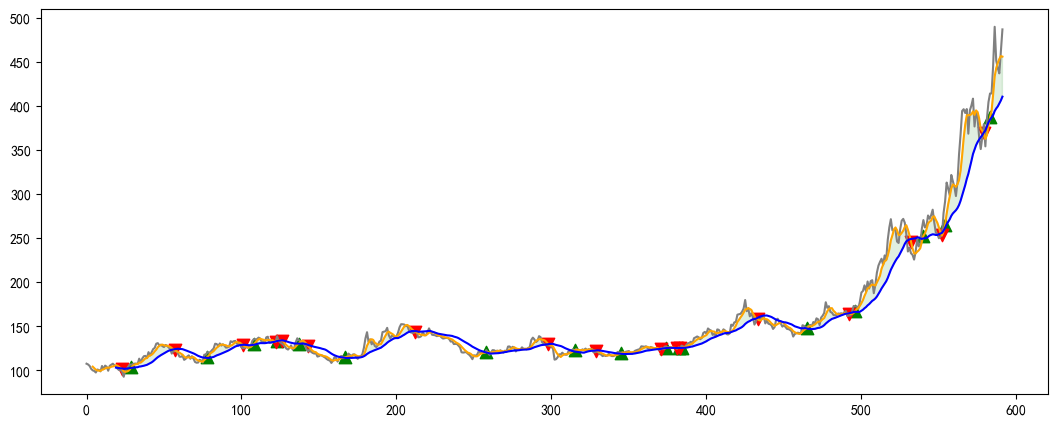

In [5]:

plt.figure(figsize=(13,5))
plt.plot(df.index, df['close'], color='gray')
plt.plot(df.index, df['MA5'], color='orange')
plt.plot(df.index, df['MA20'], color='blue')

df['spread']=df['MA5']-df['MA20']
df['cross'] = np.sign(df['spread']).diff()

golden=df[df['cross']==2].dropna(subset=['MA5','MA20'])
death=df[df['cross']==-2].dropna(subset=['MA5','MA20'])

plt.fill_between(df.index, df['MA5'], df['MA20'],
                where=(df['MA5'] >= df['MA20']),  
                interpolate=True, alpha=0.12, color='green', label='MA5 > MA20')
plt.scatter(golden.index, golden['MA5'], marker='^',s=80, color='green')
plt.scatter(death.index, death['MA5'], marker='v',s=80, color='red')


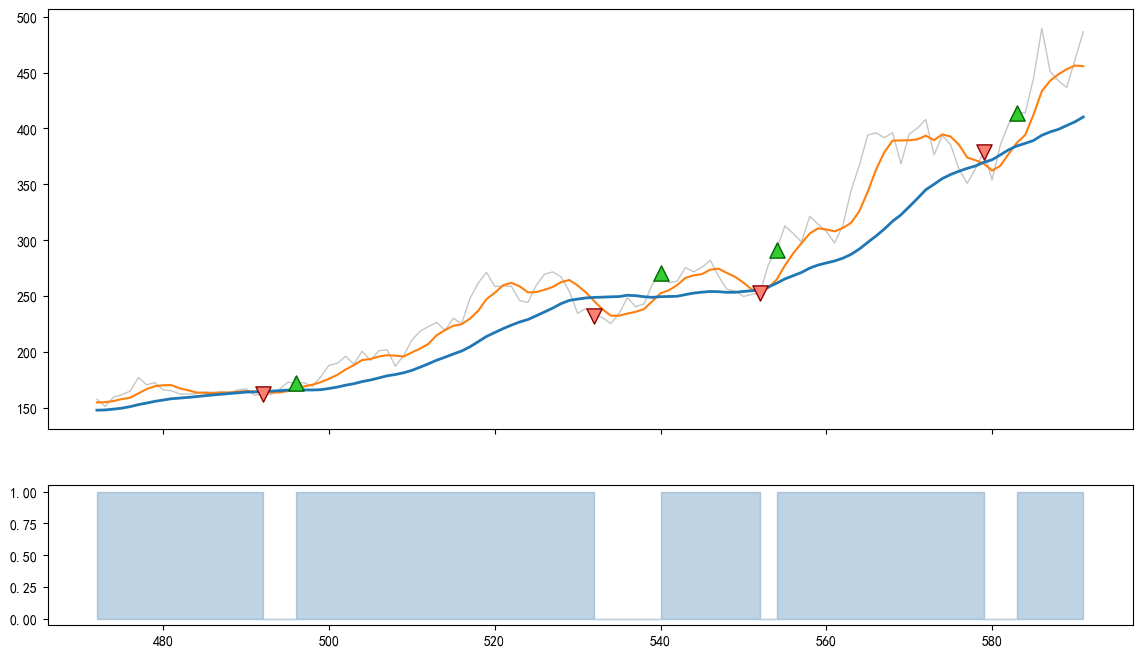

In [13]:
df['signal']=(df['MA5'] > df['MA20']).astype(int)
df['trade']=0
df.loc[df['cross']>0,'trade']=1
df.loc[df['cross'] < 0, 'trade']=-1

df = df.tail(120)
buys = df[df['trade'] == 1]
sells = df[df['trade'] == -1]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
ax_price, ax_pos = axes

ax_price.plot(df.index, df['close'], color='gray', alpha=0.45, linewidth=1, label='收盘价')
ax_price.plot(df.index, df['MA5'], color='tab:orange', linewidth=1.5, label='MA5')
ax_price.plot(df.index, df['MA20'], color='tab:blue', linewidth=2, label='MA20')

ax_price.scatter(buys.index, buys['close'], marker='^', s=120, color='limegreen',
                 edgecolors='darkgreen', linewidths=1, zorder=6, label='买入 ▲')
ax_price.scatter(sells.index, sells['close'], marker='v', s=120, color='salmon',
                 edgecolors='darkred', linewidths=1, zorder=6, label='卖出 ▼')

ax_pos.fill_between(df.index, 0, df['signal'], step='post', alpha=0.35, color='steelblue')

  [新浪] sh600522: 592 天
buy 18, sell 17


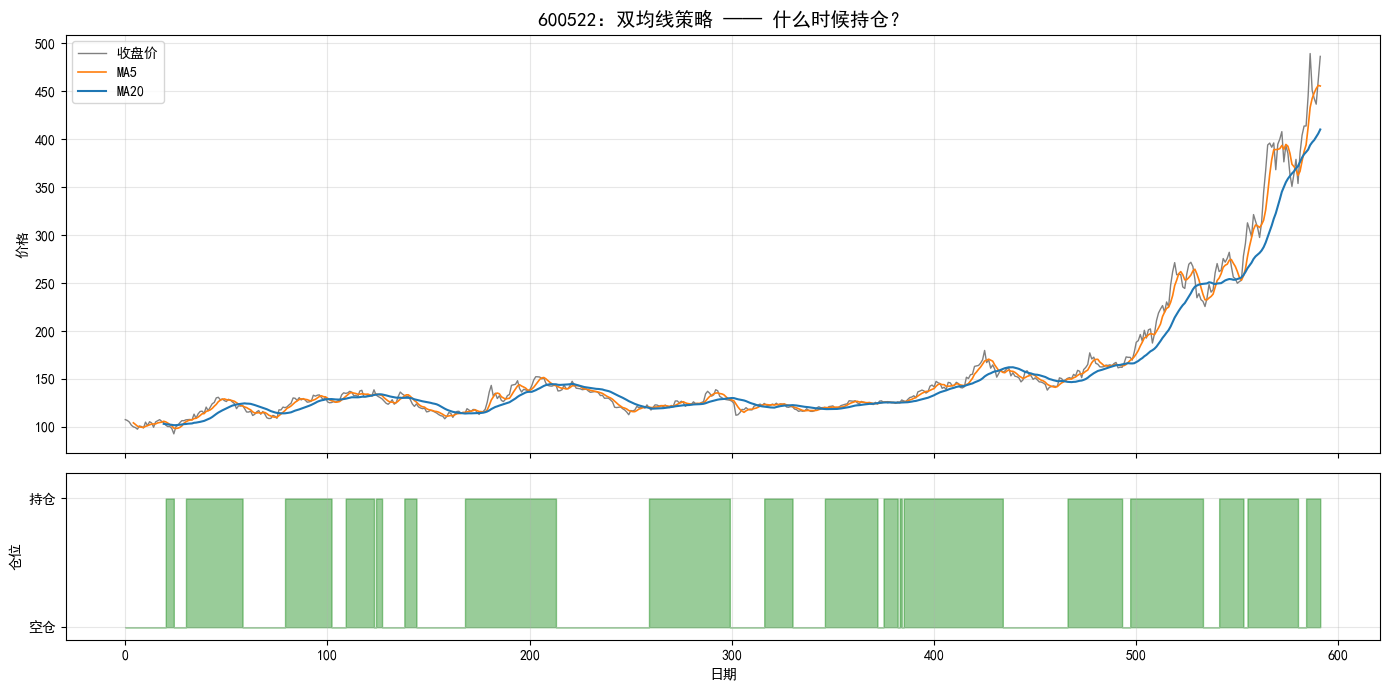

,close,MA5,MA20,signal,position,position_change,action,ret,strategy_ret,buy_hold_ret,nav_strategy,nav_buy_hold
0,107.50,NaN,NaN,0,0,0.0,,0.000000,0.000000,0.000000,1.000000,1.000000
1,106.63,NaN,NaN,0,0,0.0,,-0.008093,-0.000000,-0.008093,1.000000,0.991907
2,104.98,NaN,NaN,0,0,0.0,,-0.015474,-0.000000,-0.015474,1.000000,0.976558
3,101.69,NaN,NaN,0,0,0.0,,-0.031339,-0.000000,-0.031339,1.000000,0.945953
4,99.96,104.152,NaN,0,0,0.0,,-0.017012,-0.000000,-0.017012,1.000000,0.929860
...,...,...,...,...,...,...,...,...,...,...,...,...
587,451.03,442.656,396.8750,1,1,0.0,,-0.078572,-0.078572,-0.078572,2.952507,4.195628
588,442.68,448.426,399.1980,1,1,0.0,,-0.018513,-0.018513,-0.018513,2.897847,4.117953
589,436.66,452.974,402.6170,1,1,0.0,,-0.013599,-0.013599,-0.013599,2.858439,4.061953
590,461.36,456.244,405.9410,1,1,0.0,,0.056566,0.056566,0.056566,3.020129,4.291721


KeyError: 'nav_buyhold'

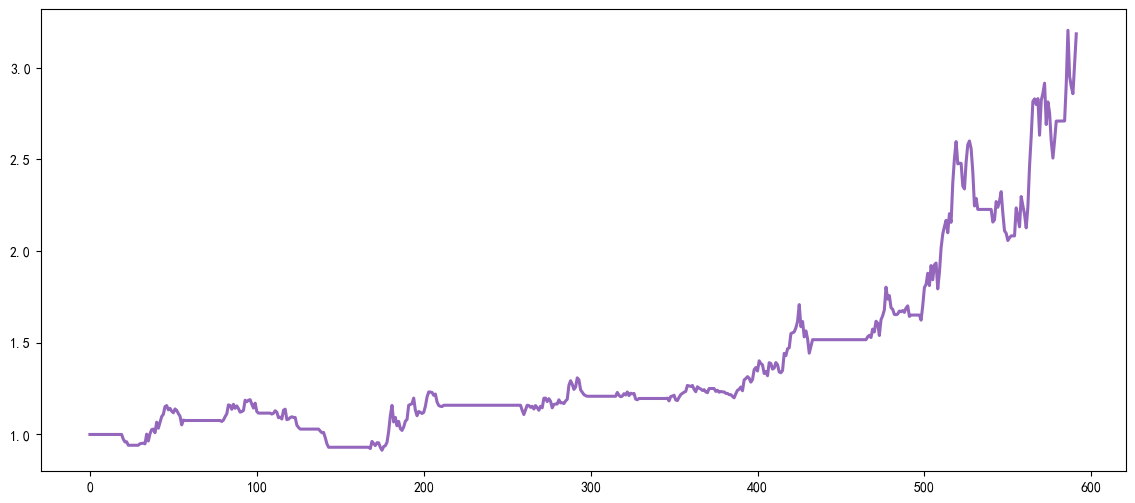

In [27]:
# 4 策略回测
TICKER = '600522'          
BENCHMARK = '399006'          # 创业板指数
PERIOD = '2y'                 # 回测样本长度

data  = get_a_stock_daily("600522","20240101","20260616", adjust="hfq")
df = data[['close']].dropna().copy()

df.columns = ['close']
df['MA5']=df['close'].rolling(5).mean()
df['MA20']=df['close'].rolling(20).mean()
df['signal']=(df['MA5']>df['MA20']).astype(int)

df['position']=df['signal'].shift(1).fillna(0).astype(int)

df['position_change']=df['position'].diff().fillna(0)
df['action']=''
df.loc[df['position_change']>0,'action']='buy'
df.loc[df['position_change']<0,'action']='sell'
print(f'buy {(df["action"]=="buy").sum()}, sell {(df["action"]=="sell").sum()}')

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                         gridspec_kw={'height_ratios': [2.5, 1]})

axes[0].plot(df.index, df['close'], color='gray', linewidth=1, label='收盘价')
axes[0].plot(df.index, df['MA5'], color='tab:orange', linewidth=1.2, label='MA5')
axes[0].plot(df.index, df['MA20'], color='tab:blue', linewidth=1.5, label='MA20')
axes[0].set_ylabel('价格')
axes[0].set_title(f'{TICKER}：双均线策略 —— 什么时候持仓？', fontsize=14)
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

axes[1].fill_between(df.index, 0, df['position'], step='post', alpha=0.4, color='green')
axes[1].set_ylim(-0.1, 1.2)
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['空仓', '持仓'])
axes[1].set_xlabel('日期')
axes[1].set_ylabel('仓位')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

df['ret'] = df['close'].pct_change().fillna(0)
df['strategy_ret']=df['position']*df['ret']

df['buy_hold_ret']=df['ret']

df['nav_strategy']=(1+df['strategy_ret']).cumprod()
df['nav_buy_hold']=(1+df['buy_hold_ret']).cumprod()

display(df)
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df['nav_strategy'], linewidth=2.2, color='tab:purple',
        label=f'双均线策略 ({TICKER})')
ax.plot(df.index, df['nav_buy_hold'], linewidth=1.8, color='tab:blue', alpha=0.85,
        label=f'买入持有 ({TICKER})')

